# TEMPEST_RAD Retrieval Analysis

This notebook performs retrieval simulations and analysis using the TEMPEST_RAD simulator.
It covers:
1.  Running TEMPEST (if needed) to generate thermal models.
2.  Comparing Smooth vs. Rough Brightness Temperatures.
3.  Spectral Analysis of individual facets.
4.  Bolometric Phase Curve analysis.
5.  Simulating an Instrument Observation (Flux integration over FOV).

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess
import shutil

# Ensure we can import from TEMPEST_RAD and src
# Adjust path to root directory relative to this notebook
current_dir = Path(os.getcwd()).resolve()
if current_dir.name == 'TEMPEST_RAD':
    root_dir = current_dir.parent
else:
    # Fallback if running from root
    root_dir = current_dir

# CHANGE WORKING DIRECTORY TO ROOT
# This ensures relative paths in config.yaml (like data/shape_models/...) work correctly
os.chdir(root_dir)
print(f"Working Directory set to: {os.getcwd()}")

sys.path.append(str(root_dir))

from src.utilities.config import Config
from src.utilities.utils import rotate_vector
from matplotlib.collections import PolyCollection
from TEMPEST_RAD.simulator import (
    load_shape_model, 
    compute_geometry, 
    RoughnessLUT, 
    planck_function, 
    rms_to_fraction, 
    calculate_theta
)

Working Directory set to: /Users/duncan/Desktop/DPhil/TEMPEST


## 1. Setup & Run TEMPEST

Define paths and run the core thermal model to generate surface temperatures.

In [2]:
# Define paths
CONFIG_PATH = os.path.join(root_dir, "private/data/config/moon/moon_config.yaml")
OUTPUT_DIR = os.path.join(root_dir, "output/retrieval_analysis")
LUT_PATH = os.path.join(root_dir, "roughness_lut_spectral_v1.h5")

print(f"--- Step 1: Running TEMPEST Simulation ---")
print(f"Config: {CONFIG_PATH}")
print(f"Output: {OUTPUT_DIR}")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Load Config and Shape Model FIRST to know what we expect
config = Config(CONFIG_PATH)
facets_expected, _ = load_shape_model(config.path_to_shape_model_file)
n_facets_expected = len(facets_expected)
print(f"Current Configuration expects {n_facets_expected} facets.")

# Find latest run
def get_latest_run_dir():
    base_out = os.path.join(root_dir, "output")
    if not os.path.exists(base_out): return None
    runs = [os.path.join(base_out, d) for d in os.listdir(base_out) if d.startswith("run_")]
    if not runs: return None
    return max(runs, key=os.path.getmtime)

print("Checking for existing TEMPEST runs...")
latest_run = get_latest_run_dir()
run_needed = True

if latest_run:
    temp_file = os.path.join(latest_run, "temperatures.csv")
    if os.path.exists(temp_file):
        # Check dimensions to ensure it matches current shape model
        try:
            # Load full file to check shape (safer than heuristic)
            temp_data = np.loadtxt(temp_file, delimiter=',')
            
            # Check if dimensions match n_facets_expected
            # TEMPEST output is usually (N_facets, N_timesteps) or transposed
            rows = temp_data.shape[0]
            cols = temp_data.shape[1] if len(temp_data.shape) > 1 else 1
            
            if rows == n_facets_expected or cols == n_facets_expected:
                print(f"Found compatible existing run: {latest_run}")
                shutil.copy(temp_file, os.path.join(OUTPUT_DIR, "temperatures.csv"))
                run_needed = False
            else:
                print(f"Existing run {latest_run} has shape {temp_data.shape}, but expected {n_facets_expected} facets. Re-running.")
        except Exception as e:
            print(f"Error checking existing run: {e}. Re-running.")
    else:
         print(f"Run folder {latest_run} found but no temperatures.csv. Re-running.")

if run_needed:
    print("Running TEMPEST... (this may take a moment)")
    cmd = ["python", "tempest.py", "--config", CONFIG_PATH]
    subprocess.run(cmd, check=True)
    
    # Get the new latest run
    latest_run = get_latest_run_dir()
    print(f"New run created at: {latest_run}")
    shutil.copy(os.path.join(latest_run, "temperatures.csv"), os.path.join(OUTPUT_DIR, "temperatures.csv"))


--- Step 1: Running TEMPEST Simulation ---
Config: /Users/duncan/Desktop/DPhil/TEMPEST/private/data/config/moon/moon_config.yaml
Output: /Users/duncan/Desktop/DPhil/TEMPEST/output/retrieval_analysis
Current Configuration expects 1280 facets.
Checking for existing TEMPEST runs...
Found compatible existing run: /Users/duncan/Desktop/DPhil/TEMPEST/output/run_2026-02-17_11-43-51


## 2. Load Data

Load the shape model, temperatures, and the Roughness Lookup Table (LUT).

In [3]:
print(f"--- Step 2: Loading Data ---")
config = Config(CONFIG_PATH)
facets, mesh = load_shape_model(config.path_to_shape_model_file)
n_facets = len(facets)

# Load Temperatures
temps_path = os.path.join(OUTPUT_DIR, "temperatures.csv")
try:
    temps_all = np.loadtxt(temps_path, delimiter=',')
except ValueError:
    temps_all = np.loadtxt(temps_path, delimiter=',', skiprows=1)

# Handle Transpose if needed
if temps_all.shape[0] != n_facets and temps_all.shape[1] == n_facets:
    temps_all = temps_all.T

print(f"Loaded temperatures: {temps_all.shape}")

# Load LUT
theta = calculate_theta(config)
print(f"Calculated Theta: {theta:.3f}")
lut = RoughnessLUT(LUT_PATH, target_theta=theta, target_rms=90.0) # Load spectral LUT

# Helper to get temps at a specific time
def get_temps_at_time(time_hours):
    period = getattr(config, 'rotation_period_hours', 24.0)
    n_steps = temps_all.shape[1]
    idx = int((time_hours % period) / period * n_steps)
    idx = np.clip(idx, 0, n_steps - 1)
    return temps_all[:, idx]

--- Step 2: Loading Data ---
Loaded temperatures: (1280, 360)
Calculated Theta: 0.028
LUT: Selected Theta=0.0316 (Target=0.02762983430898598)
LUT: Using 'opening_angle' axis.
LUT: Selected Angle=90.0 (Target=90.0)


## 3. Analysis: Brightness Temp Maps

Compare Smooth vs. Rough bolometric brightness temperature maps for a specific time and phase.

--- Step 3: Generating Brightness Temperature Maps ---

PHASE ANGLE: 0° (Time=12.0h)

=== DEBUG: Disk Center Facet (idx=0) ===
  Emission: 0.00°
  Sun Phase: 6.10°
  Latitude: 86.30°
  Azimuth: 0.00°
  Temperature: 152.62 K
  Mixing fraction f: 0.100

  Wavelength | Smooth Rad | Factor | Rough Rad | Change
  ------------------------------------------------------------
     5.0 um |  2.307e-04 | 0.102  |  2.249e-04 |  -2.51%
     8.0 um |  2.595e-02 | 0.124  |  2.529e-02 |  -2.51%
    15.0 um |  2.817e-01 | 0.372  |  2.746e-01 |  -2.51%
    50.0 um |  6.778e-02 | 0.690  |  6.608e-02 |  -2.51%
   100.0 um |  7.601e-03 | 0.749  |  7.410e-03 |  -2.51%

  Bolometric Tb: 148.96 K
  Mean visible Tb: 2.70e+02
Visible facets: 640/1280
Smooth: 330.5 K | Rough: 331.4 K | Diff: +0.85 K
  Equatorial (<30°): +1.66 K | Polar (≥60°): -1.65 K

PHASE ANGLE: 10° (Time=12.0h)
Visible facets: 640/1280
Smooth: 325.7 K | Rough: 326.5 K | Diff: +0.89 K
  Equatorial (<30°): +1.66 K | Polar (≥60°): -1.38 K

PHA

/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_81939/189576059.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)
/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_81939/189576059.py:60: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol_center = np.trapz(full_spectra[center_idx, :], x=wavelengths)
/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_81939/189576059.py:64: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  Mean visible Tb: {np.mean(np.trapz(full_spectra[visible, :], x=wavelengths, axis=1)):.2e}")


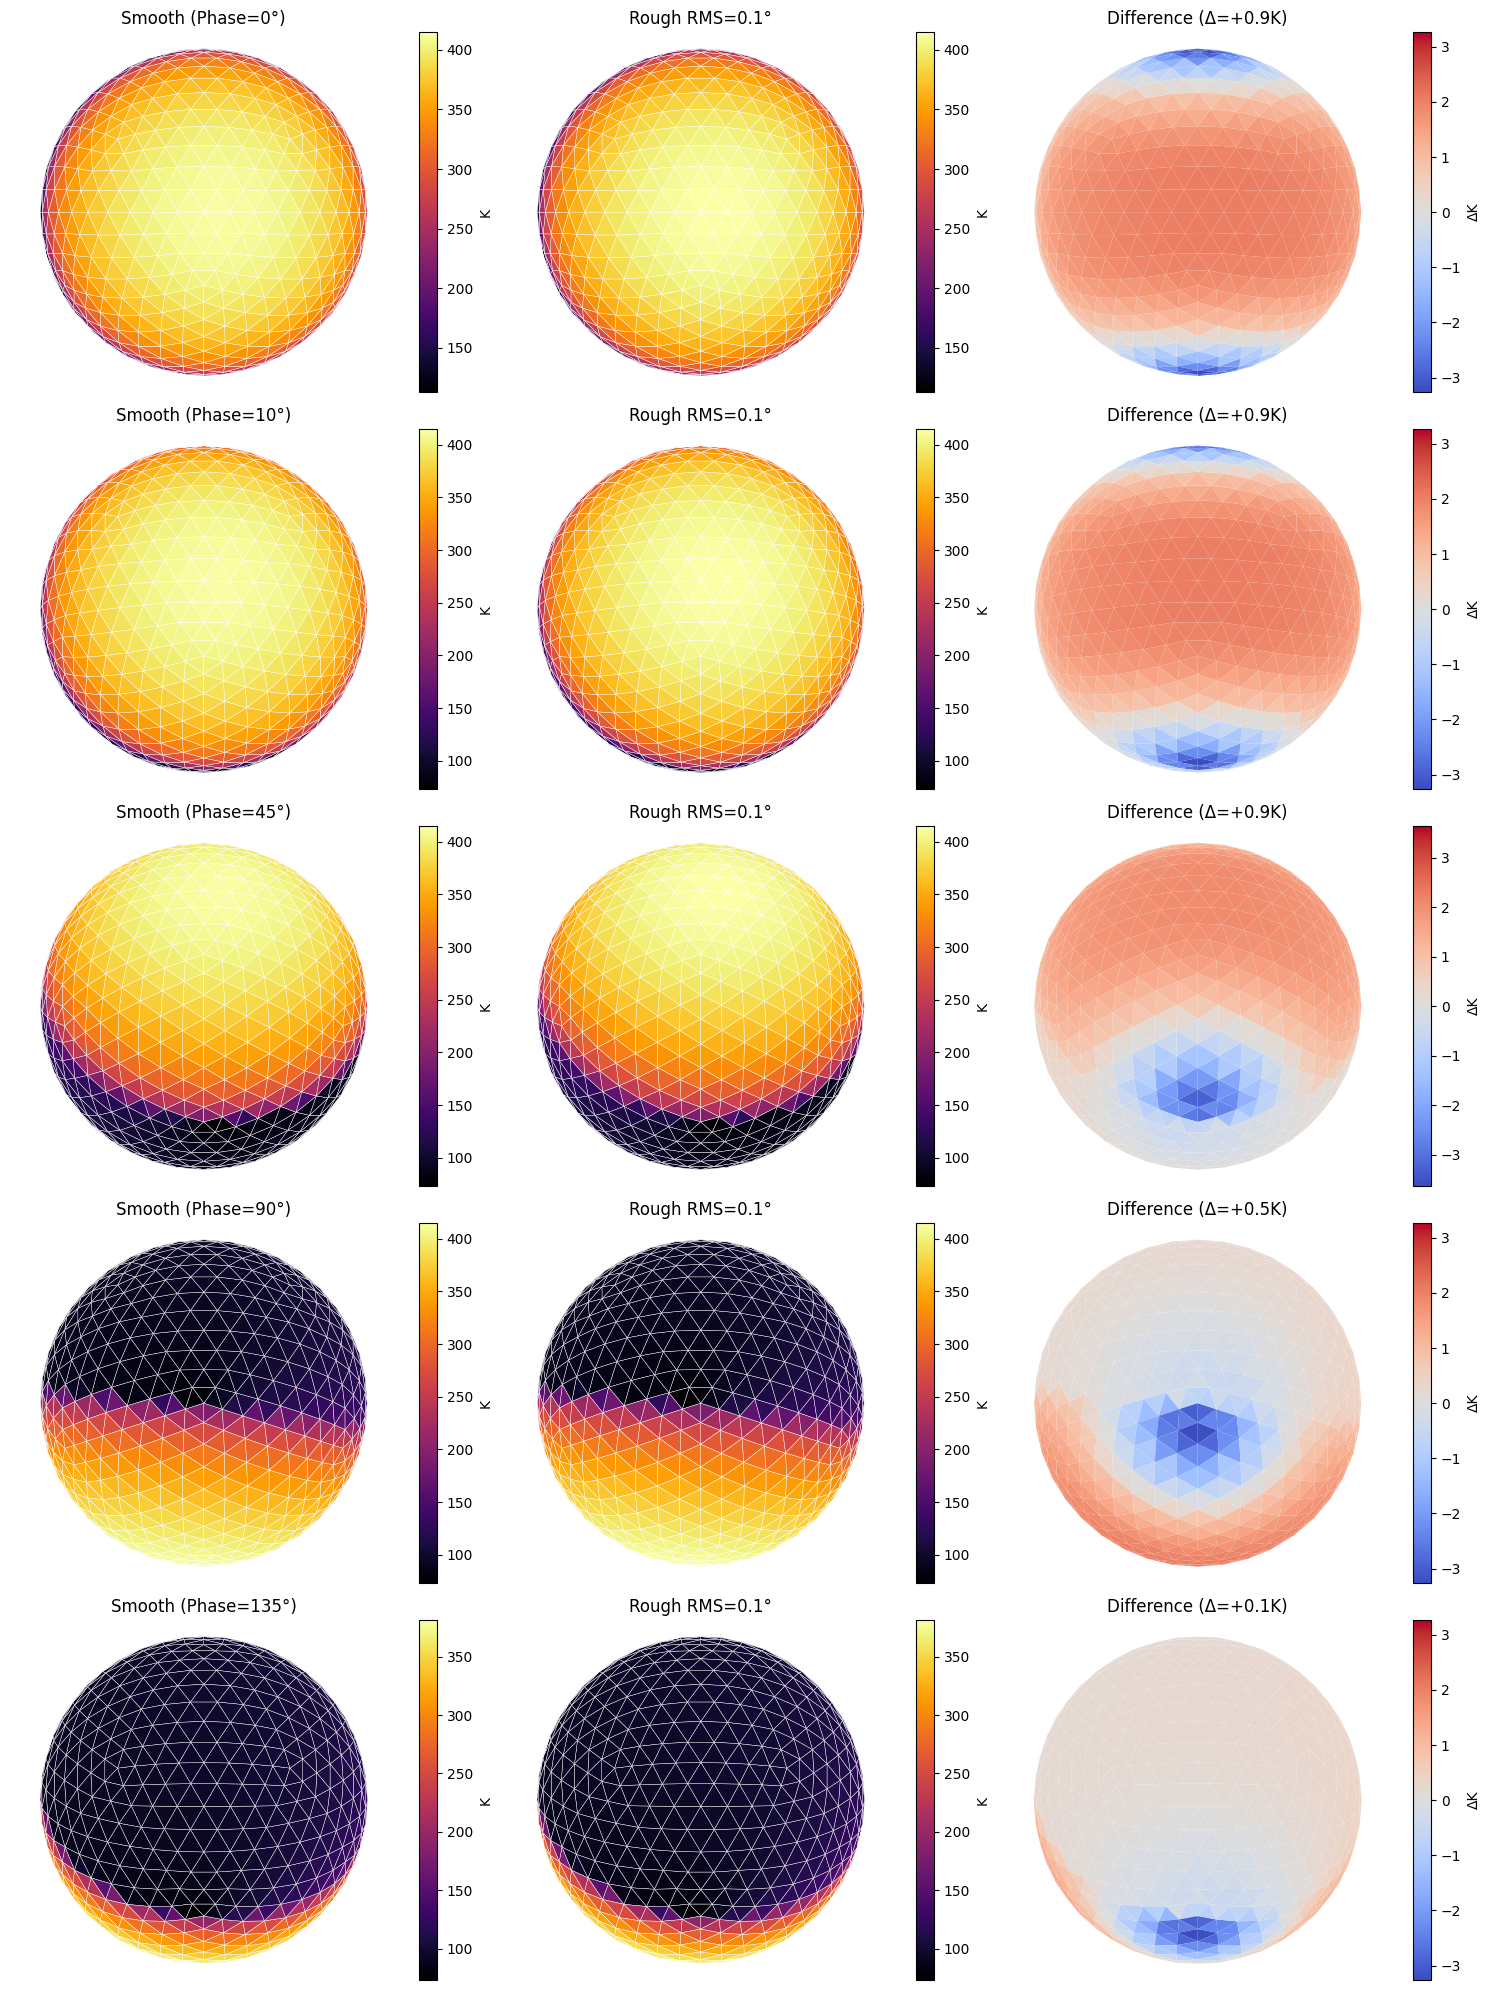

In [4]:
print(f"--- Step 3: Generating Brightness Temperature Maps ---")

def calculate_bolometric_tb(time_hours, roughness_rms, phase_angle, debug=False):
    # Geometry
    sun_vec = np.array(config.sunlight_direction)
    rot_axis = np.array([0, 0, 1]) # Simplified
    
    # Observer Vector
    perp_vec = np.cross(sun_vec, rot_axis)
    if np.linalg.norm(perp_vec) < 1e-6: perp_vec = np.array([0, 1, 0])
    obs_vec = rotate_vector(sun_vec, perp_vec, np.radians(phase_angle))
    
    lats, phases, emis, azis = compute_geometry(facets, sun_vec, obs_vec, rot_axis)
    
    # *** FIX: Override per-facet local times with global body rotation phase ***
    # The LUT expects a single rotation phase for the entire body, not per-facet local times
    period = getattr(config, 'rotation_period_hours', 24.0)
    body_rotation_phase = (time_hours / period * 360.0) % 360.0
    phases = np.full_like(phases, body_rotation_phase)  # Same phase for all facets
    
    # Temps
    temps_smooth = get_temps_at_time(time_hours)
    
    # Roughness
    f = rms_to_fraction(roughness_rms)
    
    # Wavelength Loop
    wavelengths = lut.axes['wavelength']
    full_spectra = np.zeros((n_facets, len(wavelengths)))
    
    for i, wave in enumerate(wavelengths):
        rad_smooth = planck_function(wave, temps_smooth)
        factors = lut.get_correction_factors(lats, phases, emis, azis, wavelength=wave)
        full_spectra[:, i] = rad_smooth * ((1.0 - f) + f * factors)
        
    # DEBUG OUTPUT
    if debug and roughness_rms > 0:
        # Find disk center facet (lowest emission angle)
        center_idx = np.argmin(emis)
        print(f"\n=== DEBUG: Disk Center Facet (idx={center_idx}) ===")
        print(f"  Emission: {emis[center_idx]:.2f}°")
        print(f"  Sun Phase: {phases[center_idx]:.2f}°")
        print(f"  Latitude: {lats[center_idx]:.2f}°")
        print(f"  Azimuth: {azis[center_idx]:.2f}°")
        print(f"  Temperature: {temps_smooth[center_idx]:.2f} K")
        print(f"  Mixing fraction f: {f:.3f}")
        print(f"\n  Wavelength | Smooth Rad | Factor | Rough Rad | Change")
        print(f"  " + "-"*60)
        for i, wave in enumerate(wavelengths):
            rad_s = full_spectra[center_idx, i] / ((1.0 - f) + f * factors[center_idx])  # Back-calculate smooth
            rad_r = full_spectra[center_idx, i]
            factor = factors[center_idx]
            # Get the actual factor used
            factors_wave = lut.get_correction_factors(lats, phases, emis, azis, wavelength=wave)
            change = ((rad_r / rad_s) - 1.0) * 100 if rad_s > 0 else 0
            print(f"  {wave:6.1f} um | {rad_s:10.3e} | {factors_wave[center_idx]:.3f}  | {rad_r:10.3e} | {change:+6.2f}%")
        
        # Bolometric
        visible = emis < 90
        rad_bol_center = np.trapz(full_spectra[center_idx, :], x=wavelengths)
        sigma = 5.670374419e-8
        t_eff_center = (np.pi * rad_bol_center / sigma) ** 0.25
        print(f"\n  Bolometric Tb: {t_eff_center:.2f} K")
        print(f"  Mean visible Tb: {np.mean(np.trapz(full_spectra[visible, :], x=wavelengths, axis=1)):.2e}")
        
    # Integrate
    rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)
    sigma = 5.670374419e-8
    t_eff = (np.pi * rad_bol / sigma) ** 0.25
    
    # Mask hidden
    t_eff[emis > 90] = 0
    
    return t_eff, obs_vec, emis

# Compare at multiple phase angles
time_tgt = 12.0
roughness_rms = 0.1
phase_angles_to_plot = [0, 10, 45, 90, 135]  # Forward scattering and backscattering

# Projection helper
def project_polys(obs_vec, mesh_vectors):
    obs_n = obs_vec / np.linalg.norm(obs_vec)
    up = np.array([0, 0, 1])
    if abs(np.dot(up, obs_n)) > 0.9: up = np.array([1, 0, 0])
    u = np.cross(obs_n, up); u /= np.linalg.norm(u)
    v = np.cross(obs_n, u)
    
    # Project vertices (N, 3, 3)
    u_verts = np.dot(mesh_vectors, u)
    v_verts = np.dot(mesh_vectors, v)
    return np.stack((u_verts, v_verts), axis=2)

# Create figure with subplots for each phase angle
n_phases = len(phase_angles_to_plot)
fig, axes = plt.subplots(n_phases, 3, figsize=(15, 4*n_phases))
if n_phases == 1:
    axes = axes.reshape(1, -1)

for row_idx, phase_tgt in enumerate(phase_angles_to_plot):
    print(f"\n{'='*70}")
    print(f"PHASE ANGLE: {phase_tgt}° (Time={time_tgt}h)")
    print(f"{'='*70}")
    
    tb_smooth, obs_vec, emis = calculate_bolometric_tb(time_tgt, 0.0, phase_tgt, debug=False)
    tb_rough, _, _ = calculate_bolometric_tb(time_tgt, roughness_rms, phase_tgt, debug=(phase_tgt==0))
    
    # Summary Statistics
    visible = emis < 90
    mean_s = np.mean(tb_smooth[visible])
    mean_r = np.mean(tb_rough[visible])
    
    print(f"Visible facets: {np.sum(visible)}/{len(facets)}")
    print(f"Smooth: {mean_s:.1f} K | Rough: {mean_r:.1f} K | Diff: {mean_r - mean_s:+.2f} K")
    
    # Check for latitude bias in diff
    lats_temp, _, emis_temp, _ = compute_geometry(facets, np.array(config.sunlight_direction), obs_vec, np.array([0,0,1]))
    equatorial = (np.abs(lats_temp) < 30) & visible
    polar = (np.abs(lats_temp) >= 60) & visible
    
    if np.sum(equatorial) > 0 and np.sum(polar) > 0:
        diff_eq = np.mean(tb_rough[equatorial]) - np.mean(tb_smooth[equatorial])
        diff_polar = np.mean(tb_rough[polar]) - np.mean(tb_smooth[polar])
        print(f"  Equatorial (<30°): {diff_eq:+.2f} K | Polar (≥60°): {diff_polar:+.2f} K")
    
    # Plot
    polys = project_polys(obs_vec, mesh.vectors)
    mask = visible
    
    # Global colorbar limits for consistency
    vmin_tb = min(np.min(tb_smooth[mask]), np.min(tb_rough[mask]))
    vmax_tb = max(np.max(tb_smooth[mask]), np.max(tb_rough[mask]))
    
    # Smooth
    coll1 = PolyCollection(polys[mask], array=tb_smooth[mask], cmap='inferno', edgecolors='white', linewidths=0.3)
    coll1.set_clim(vmin_tb, vmax_tb)
    axes[row_idx, 0].add_collection(coll1)
    axes[row_idx, 0].set_title(f"Smooth (Phase={phase_tgt}°)")
    axes[row_idx, 0].autoscale()
    axes[row_idx, 0].axis('equal')
    axes[row_idx, 0].axis('off')
    plt.colorbar(coll1, ax=axes[row_idx, 0], label="K", fraction=0.046)
    
    # Rough
    coll2 = PolyCollection(polys[mask], array=tb_rough[mask], cmap='inferno', edgecolors='white', linewidths=0.3)
    coll2.set_clim(vmin_tb, vmax_tb)
    axes[row_idx, 1].add_collection(coll2)
    axes[row_idx, 1].set_title(f"Rough RMS={roughness_rms}°")
    axes[row_idx, 1].autoscale()
    axes[row_idx, 1].axis('equal')
    axes[row_idx, 1].axis('off')
    plt.colorbar(coll2, ax=axes[row_idx, 1], label="K", fraction=0.046)
    
    # Difference
    diff = tb_rough - tb_smooth
    vmax_diff = max(1.0, np.max(np.abs(diff[mask])))  # At least ±1K range
    coll3 = PolyCollection(polys[mask], array=diff[mask], cmap='coolwarm', edgecolors='face', linewidths=0.0)
    coll3.set_clim(-vmax_diff, vmax_diff)
    axes[row_idx, 2].add_collection(coll3)
    axes[row_idx, 2].set_title(f"Difference (Δ={mean_r-mean_s:+.1f}K)")
    axes[row_idx, 2].autoscale()
    axes[row_idx, 2].axis('equal')
    axes[row_idx, 2].axis('off')
    plt.colorbar(coll3, ax=axes[row_idx, 2], label="ΔK", fraction=0.046)

plt.tight_layout()
plt.show()

## 5. Analysis: Phase Curve Variation

Calculate the mean disk brightness temperature across varied phase angles.

--- Step 5: Phase Curve Analysis ---


/var/folders/s0/bdhfq4xd0bv2l81msn973wb40000gs/T/ipykernel_81939/189576059.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rad_bol = np.trapz(full_spectra, x=wavelengths, axis=1)


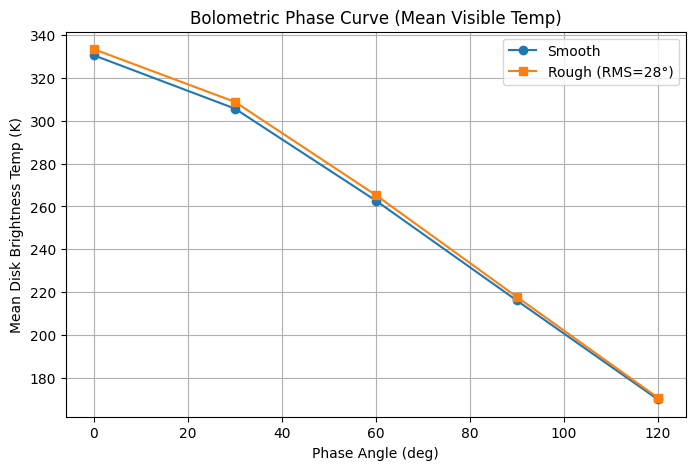

In [ ]:
print(f"--- Step 5: Phase Curve Analysis ---")

phases_to_test = [0, 30, 60, 90, 120, 150, 180]
mean_temps_smooth = []
mean_temps_rough = []

for p in phases_to_test:
    # Calculate maps
    tb_s, _, emi_s = calculate_bolometric_tb(time_tgt, 0.0, p)
    tb_r, _, emi_r = calculate_bolometric_tb(time_tgt, 28.0, p)
    
    # Average over visible disk (simple mean for now, ideally area-weighted)
    mask_s = emi_s < 90
    mask_r = emi_r < 90
    
    mean_temps_smooth.append(np.mean(tb_s[mask_s]))
    mean_temps_rough.append(np.mean(tb_r[mask_r]))

plt.figure(figsize=(8, 5))
plt.plot(phases_to_test, mean_temps_smooth, 'o-', label='Smooth')
plt.plot(phases_to_test, mean_temps_rough, 's-', label='Rough (RMS=28°)')
plt.xlabel("Phase Angle (deg)")
plt.ylabel("Mean Disk Brightness Temp (K)")
plt.title("Bolometric Phase Curve (Mean Visible Temp)")
plt.legend()
plt.grid(True)
plt.show()